# Analyze fitness effects

Import Python modules

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import glob
from collections import defaultdict
import math
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.0, style='ticks', palette='colorblind')
import scipy
from Bio import SeqIO
from Bio.Seq import Seq

In [2]:
# Show all columns
pd.set_option('display.max_columns', None)

Read in alignments and create a dataframe that maps alignment sites to site in specific reference sequences.

HA
H1 MKANLLV-LLCALAA--------ADADTICIGYHANNSTDTVDTVLEKNVTVTHSVNLLEDSHNGKLCRLKGIAPLQLGKCNIAGWLLGNPECDPLLPVRSWSYIVETPNSENGICYPGDFIDYEELREQLSSVSSFERFEIFPKESSWPNHNTTKGVTAACSHAGKSSFYRNLLWLTE--KEGSYPKLKNSYVNKKGKEVLVLWGIHHPSNSKDQQNIYQNENAYVSVVTSNYNRRFTPEIAERPKVRDQAGRMNYYWTLLKPGDTIIFEANGNLIAPRYAFALSRGFGSGIITSNAS-MHECNTKCQTPLGAINSSLPFQNIHPVTIGECPKYVRSAKLRMVTGLRNIPSI----QSRGLFGAIAGFIEGGWTGMIDGWYGYHHQNEQGSGYAADQKSTQNAINGITNKVNSVIEKMNIQFTAVGKEFNKLEKRMENLNKKVDDGFLDIWTYNAELLVLLENERTLDFHDSNVKNLYEKVKSQLKNNAKEIGNGCFEFYHKCDNECMESVRNGTYDYPKYSEESKLNREKVDGVKLESMGIYQILAIYSTVASSLVLLVSLGAISFWMCSNGSLQCRICI*
H3 MKTIIALSYIFCLALGQDLPGNDNSTATLCLGHHAVPNGTLVKTITDDQIEVTNATELVQSSSTGKICN-NPHRILDGIDCTLIDALLGDPHCDVFQN-ETWDLFVERSKA-FSNCYPYDVPDYASLRSLVASSGTLEFITE---GFTWTG-VTQNGGSNACKRGPGNGFFSRLNWLTK--SGSTYPVLNVTMPNNDNFDKLYIWGIHHPSTNQEQTSLYVQASGRVTVSTRRSQQTIIPNIGSRPWVRGLSSRISIYWTIVKPGDVLVINSNGNLIAPRGYFKMRT-GKSSIMRSDAP-IDTCISECITPNGSIPNDKPFQNVNKITYGACPKYVKQNTLKLATGMRNVPEK----QTRGLFGAIAGFIENGWEGMIDGWYGFRHQNSEGTGQAADLKSTQAAIDQ

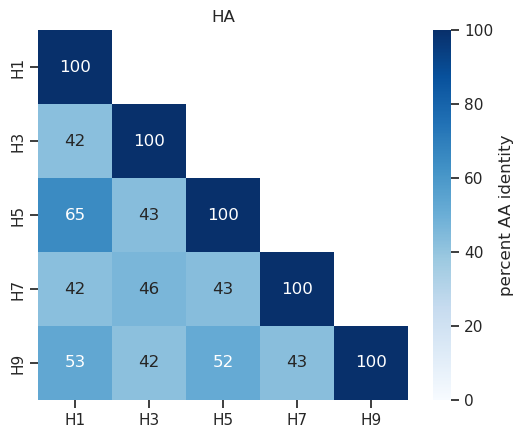

NA
N1 MNPNQKIITIGSICLVVGLISLILQIGNIISIWISHSIQ-----TGSQNHTGICNQNIIT-------YKNSTWV-----KDT-T-S-V-ILTGNSSLCPIRGWAIYSKDNSIRIGSKGDVFVIREPFISCSHLECRTFFLTQGALLNDRHSNGTVKDRSPYRALMSCPVGEAPSPYNSRFESVAWSASACHDGMGWLTIGISGPDNGAVAVLKYNGIITETIKSWRKKILRTQESECACVNGSCFTIMTDGPSDGLASYKIFKIEKGKVTKSIELNAPNSHYEECSCYPDTGKVMCVCRDNWHGSNRPWVSFDQN-LDYQIGYICSGVFGDNPRPKDGT--GSCG-PVYVDGANGVKGFSYRYGNGVWIGRTKSHSSRHGFEMIWDPNGWTETDSKFSV-RQDVVAMTDWSGYSGSFVQHPELTGLDCIRPCFWVELIRGRPKEKTI-WTSASSISFCGVNSDTVDWSWPDGAELPFTIDK*
N2 MNPNQKIITIGSVSLTIATVCFLMQIAILVTTVTLHFKQYECD-SPASNQVMPCEPIIIERNITEIVYLNNTTI-----EKEICPKVVEYRNWSKPQCQITGFAPFSKDNSIRLSAGGDIWVTREPYVSCDHGKCYQFALGQGTTLDNKHSNDTIHDRIPHRTLLMNELGV-PFHLGTRQVCIAWSSSSCHDGKAWLHVCITGDDKNATASFIYDGRLVDSIGSWSQNILRTQESECVCINGTCTVVMTDGSASGRADTRILFIEEGKIVHISPLSGSAQHVEECSCYPRYPGVRCICRDNWKGSNRPVVDINMEDYSIDSSYVCSGLVGDTPRNDDRSSNSNCRNPNNERGNQGVKGWAFDNGDDVWMGRTISKDLRSGYETFKVIGGWSTPNSKSQINRQVIVDSDNRSGYSGIFSV----EGKSCINRCFYVELIRGRKQETRVWWTSNSIVVFCGTSGTYGTGSWPDGANINFM-PI*
N9 MNPNQKILCTSATAIIIGAIAV

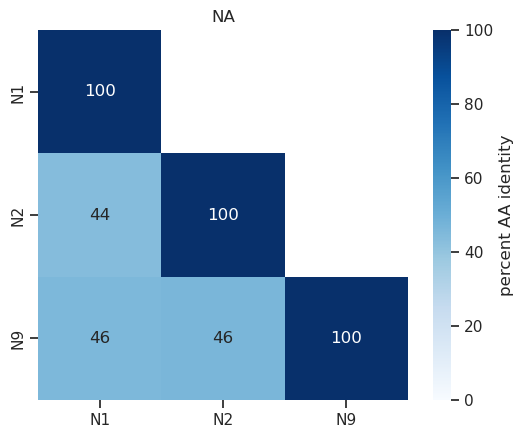

In [3]:
# Compute a pairwise identity matrix
def compute_pairwise_identity(records):
    seqs = [str(record.seq) for record in records]
    n = len(seqs)
    identity_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            n_sites_to_compare = 0
            n_identical_sites = 0
            for (a, b) in zip(seqs[i], seqs[j]):
                if a != '-' and b != '-':
                    n_sites_to_compare += 1
                    if a == b:
                        n_identical_sites += 1
            assert n_sites_to_compare > 0, f"No sites to compare between {records[i].id} and {records[j].id}"            
            identity = n_identical_sites / n_sites_to_compare * 100
            identity_matrix[i, j] = identity
            identity_matrix[j, i] = identity

    return pd.DataFrame(identity_matrix, index=[record.id for record in records], columns=[record.id for record in records])

# Read in aligned sequences
numbering_dict = defaultdict(list)
for segment in ['HA', 'NA']:
    alignment_files = glob.glob(f'../results/aligned_proteins/{segment}/*.fasta')
    for alignment_file in alignment_files:

        # Get gene name
        gene = os.path.basename(alignment_file).split('.')[0].replace('_aligned', '')
        print(gene)

        # Read in records and sort them
        records = list(SeqIO.parse(alignment_file, 'fasta'))
        records.sort(key=lambda x: x.id)
        
        # Iterate over each site in the alignment, record its index and the
        # index of each sequence (ignoring gaps)
        alignment_length = len(records[0].seq)
        for record in records:
            print(record.id, record.seq)
            (subtype, segment, gene_id) = record.description.split(' ')
            assert gene == gene_id
            seq = str(record.seq)
            seq_index = 1
            for alignment_index in range(1, alignment_length + 1):
                wt_aa = seq[alignment_index - 1]
                if wt_aa != '-':
                    numbering_dict['subtype'].append(subtype)
                    numbering_dict['segment'].append(segment)
                    numbering_dict['gene'].append(gene)
                    numbering_dict['alignment_index'].append(alignment_index)
                    numbering_dict['codon_site'].append(seq_index)
                    numbering_dict['wt_aa'].append(wt_aa)
                    seq_index += 1

        # Compute a pairwise identity matrix
        df = compute_pairwise_identity(records)
        # Plot the pairwise identity matrix as a heatmap, only showing the lower triangle
        mask = np.triu(np.ones_like(df, dtype=bool), k=1)
        sns.heatmap(
            df, cmap='Blues', annot=True, fmt='.0f', square=True, mask=mask,
            vmin=0, vmax=100, cbar_kws={'label': 'percent AA identity'}
        )
        plt.title(gene)
        plt.show()

numbering_df = pd.DataFrame(numbering_dict)

# Save dataframe to file
out_file = '../results/alignment_numbering.csv'
if not os.path.isfile(out_file):
    numbering_df.to_csv(out_file, index=False)

Compute fitness effects

In [4]:
# Read in counts
counts_df = pd.read_csv('../results/counts.csv', keep_default_na=False)
counts_df = counts_df.replace('', np.nan)

# Compute genome-wide rates
genome_wide_rates = (
    counts_df[
        (counts_df['evo_opp'] > 0.1) &
        (counts_df['mut_class'] == 'synonymous')
    ]
    .groupby('mut_type', as_index=False)[['actual_count', 'evo_opp']].sum()
    .assign(expected_rate_gw = lambda x: x['actual_count'] / x['evo_opp'])
)

# Read in parameters from neutral model
model_df = pd.read_csv('../results/all_rows/local_context+global_context/table.csv', keep_default_na=False)
del model_df['Unnamed: 0']
del model_df['tau_squared']
model_df.rename(columns={'predicted_rate' : 'expected_rate_nm'}, inplace=True)

# Merge expected rates and compute expected counts
fitness_df = (
    counts_df
    .assign(gene=lambda x: x['gene'].str.upper())
    .merge(genome_wide_rates[['mut_type', 'expected_rate_gw']])
    .merge(model_df, on=['mut_type', 'segment', 'motif'])
    .assign(expected_count_gw=lambda x: x['expected_rate_gw'] * x['evo_opp'])
    .assign(expected_count=lambda x: x['expected_rate_nm'] * x['evo_opp'])
)

# Then compute fitness effects at the level of synonymous nucleotide mutations, aggregating data
# for mutations away from the same wildtype nucleotide at the same site
pseudo_count = 0.5
groupby_cols = [
    'subtype', 'segment', 'gene', 'site', 'codon_site', 'wt_nt', 'mut_class'
]
nt_fitness_df = (
    fitness_df
    .query("mut_class == 'synonymous'")
    .groupby(groupby_cols, as_index=False)
    .agg(
        {
            'actual_count': 'sum',
            'expected_count_gw': 'sum',
            'expected_count': 'sum'
        }
    )
    .assign(
        delta_fitness_gw=lambda x: \
            np.log((x['actual_count'] + pseudo_count) / (x['expected_count_gw'] + pseudo_count))
    )
    .assign(
        delta_fitness=lambda x: \
            np.log((x['actual_count'] + pseudo_count) / (x['expected_count'] + pseudo_count))
    )
)

# ... and at the level of amino-acid mutations, aggregating data for the same amino-acid
# mutations at the same site
groupby_cols = [
    'subtype', 'segment', 'gene', 'codon_site', 'wt_aa', 'mut_aa', 'aa_mut',
    'mut_class'
]
fitness_df = (
    fitness_df
    .groupby(groupby_cols, as_index=False)
    .agg(
        {
            'actual_count': 'sum',
            'expected_count_gw': 'sum',
            'expected_count': 'sum'
        }
    )
    .assign(
        delta_fitness_gw=lambda x: \
            np.log((x['actual_count'] + pseudo_count) / (x['expected_count_gw'] + pseudo_count))
    )
    .assign(
        delta_fitness=lambda x: \
            np.log((x['actual_count'] + pseudo_count) / (x['expected_count'] + pseudo_count))
    )
)
fitness_df.head()

,subtype,segment,gene,codon_site,wt_aa,mut_aa,aa_mut,mut_class,actual_count,expected_count_gw,expected_count,delta_fitness_gw,delta_fitness
0,H1,HA,HA,1,K,K,K1K,synonymous,0,0.012491,0.010289,-0.024676,-0.020369
1,H1,HA,HA,1,K,M,K1M,nonsynonymous,0,0.000970,0.000942,-0.001938,-0.001882
2,H1,HA,HA,1,K,N,K1N,nonsynonymous,0,0.002285,0.001551,-0.004560,-0.003097
3,H1,HA,HA,1,K,R,K1R,nonsynonymous,0,0.005990,0.004577,-0.011909,-0.009113
4,H1,HA,HA,1,K,T,K1T,nonsynonymous,0,0.000650,0.000591,-0.001300,-0.001181


In [ ]:
fitness_df[
    fitness_df['expected_count'] >= 10
].groupby(['subtype', 'gene']).size()

subtype  gene      
H1       HA            3265
H3       HA            3211
H5       HA            1752
H9       HA            1310
N1       NA            2919
N2       NA            2803
all      M1            1500
         M2             509
         M2;M1          194
         NEP            275
         NEP;NS1        702
         NP            3587
         NS1           1158
         PA            4742
         PB1           4386
         PB1;PB1-F2     890
         PB2           5105
dtype: int64

In [6]:
fitness_df[
    (fitness_df['mut_class'] == 'synonymous') &
    (fitness_df['expected_count'] >= 10)
].groupby(['subtype', 'gene']).size()

subtype  gene      
H1       HA            614
H3       HA            592
H5       HA            528
H9       HA            440
N1       NA            519
N2       NA            521
all      M1            249
         M2             91
         M2;M1           8
         NEP            46
         NEP;NS1        13
         NP            541
         NS1           211
         PA            750
         PB1           661
         PB1;PB1-F2      9
         PB2           773
dtype: int64

In [7]:
nt_fitness_df[
    (nt_fitness_df['mut_class'] == 'synonymous') &
    (nt_fitness_df['expected_count'] >= 10)
].groupby(['subtype', 'segment']).size()

subtype  segment
H1       HA          740
H3       HA          657
H5       HA          595
H9       HA          424
N1       NA          790
N2       NA          646
all      MP          529
         NP         1019
         NS          422
         PA         1313
         PB1        1234
         PB2        1522
dtype: int64

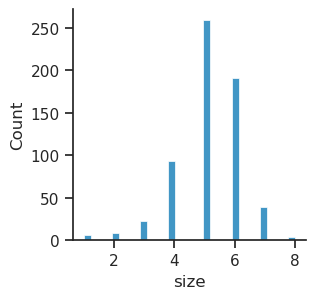

             size
count  624.000000
mean     5.145833
std      1.083755
min      1.000000
25%      5.000000
50%      5.000000
75%      6.000000
max      8.000000


,codon_site,wt_aa,size
248,292,R,1
544,546,V,1
309,342,R,1
184,238,W,1
154,213,R,1
...,...,...,...
600,80,C,7
614,92,C,8
326,358,G,8
474,489,C,8


In [24]:
data = fitness_df[
    (fitness_df['gene'] == 'HA') &
    (fitness_df['subtype'] == 'H3') &
    (fitness_df['expected_count'] >= 10)
].copy()

muts_per_site = (
    data
    .groupby(['codon_site', 'wt_aa'], as_index=False).size()
    .sort_values('size')
)
plt.figure(figsize=(3,3))
sns.histplot(x='size', data=muts_per_site)
sns.despine()
plt.show()
print(muts_per_site.describe())
muts_per_site

In [26]:
data[data['codon_site'] == '80']

,subtype,segment,gene,codon_site,wt_aa,mut_aa,aa_mut,mut_class,actual_count,expected_count_gw,expected_count,delta_fitness_gw,delta_fitness
32310,H3,HA,HA,80,C,*,C80*,nonsense,0,63.468194,42.458363,-4.851533,-4.453379
32311,H3,HA,HA,80,C,C,C80C,synonymous,65,137.668977,68.594532,-0.746427,-0.053425
32312,H3,HA,HA,80,C,F,C80F,nonsynonymous,0,41.239017,25.166997,-4.424584,-3.938353
32313,H3,HA,HA,80,C,G,C80G,nonsynonymous,0,13.750230,11.893023,-3.349920,-3.210281
32314,H3,HA,HA,80,C,R,C80R,nonsynonymous,1,108.712011,54.769969,-4.287826,-3.606765
32315,H3,HA,HA,80,C,S,C80S,nonsynonymous,0,18.548564,29.381666,-3.640139,-4.090392
32317,H3,HA,HA,80,C,Y,C80Y,nonsynonymous,2,225.414243,125.250256,-4.503865,-3.918007


For a given gene, plot the cumulative distribution of expected counts for all mutations with expected counts greater than or equal to 10.

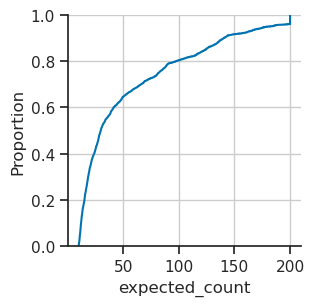

In [23]:
data = fitness_df[
    (fitness_df['expected_count'] >= 10) &
    (fitness_df['gene'] == 'HA')
].copy()
data['expected_count'] = data['expected_count'].clip(upper=200)

plt.figure(figsize=[3,3])
sns.ecdfplot(data['expected_count'])
plt.grid()
sns.despine()
plt.show()

Plot distributions of fitness effects

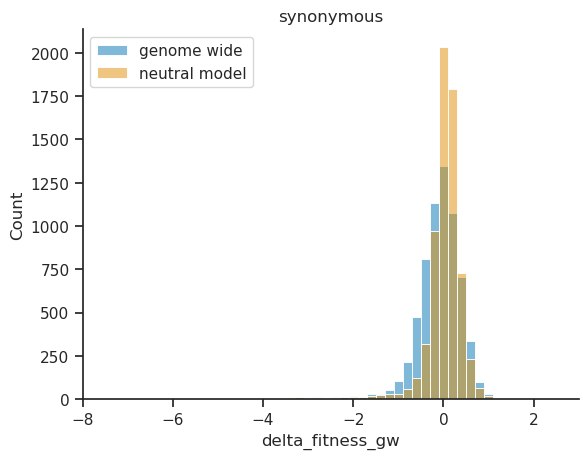

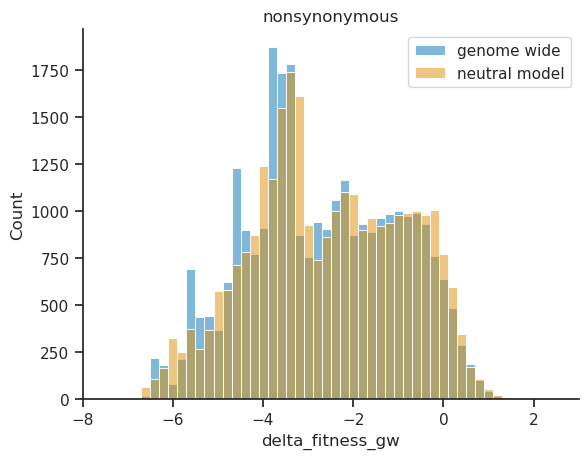

In [24]:
mut_classes = ['synonymous', 'nonsynonymous']
bins = np.arange(-7.5, 2.7, 0.2)
for mut_class in mut_classes:
    data = fitness_df[
        (fitness_df['expected_count'] >= 10) &
        (fitness_df['expected_count_gw'] >= 10) &
        (fitness_df['mut_class'] == mut_class)
    ].copy()
    sns.histplot(x=f'delta_fitness_gw', data=data, bins=bins, label='genome wide', alpha=0.5)
    sns.histplot(x=f'delta_fitness', data=data, bins=bins, label='neutral model', alpha=0.5)
    plt.title(mut_class)
    sns.despine()
    plt.legend()
    plt.show()

In [25]:
mut_class_colors = {
    'synonymous' : '#0173b2',
    'nonsynonymous' : '#de8f05',
    'nonsense' : 'firebrick',
}

25881


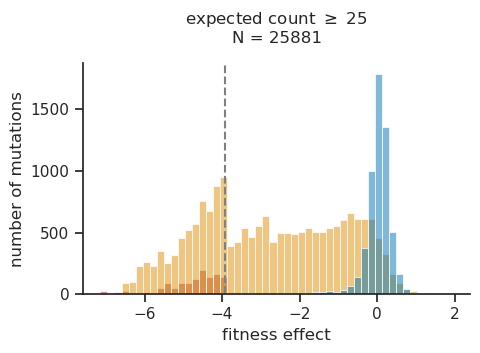

In [26]:
count_threshold = 25
data = fitness_df[
    # (fitness_df['gene'] == 'HA') &
    # (fitness_df['subtype'] == 'H3') &
    (fitness_df['expected_count'] >= count_threshold)
].copy()
print(len(data))
fitness_lod = np.log(0.5/(count_threshold+0.5))
data['delta_fitness'] = data['delta_fitness'].clip(upper=2.0)
plt.figure(figsize=(5,3))
ax = sns.histplot(
    x='delta_fitness', data=data, bins=50,
    hue='mut_class', hue_order=['synonymous', 'nonsynonymous', 'nonsense'],
    palette=mut_class_colors, legend=False
)
plt.axvline(fitness_lod, color='gray', linestyle='--')
plt.xlabel('fitness effect')
plt.ylabel('number of mutations')
plt.title(f'expected count $\geq$ {count_threshold}\nN = {len(data)}', y=1.05)
sns.despine()
plt.show()

Plot distributions of fitness effects as a function of gene.

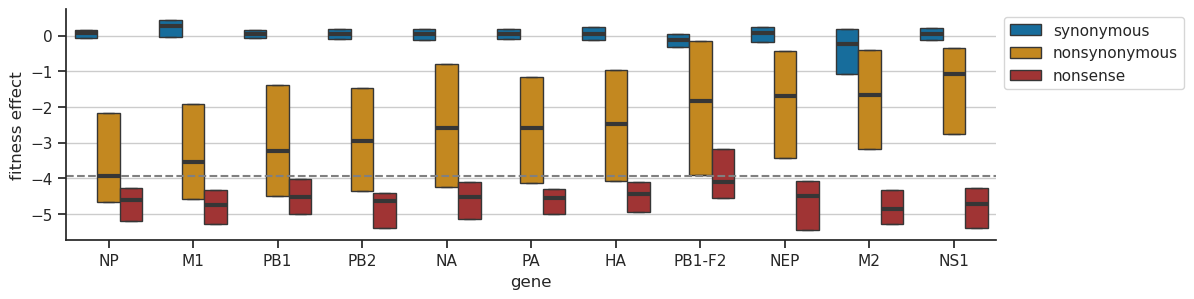

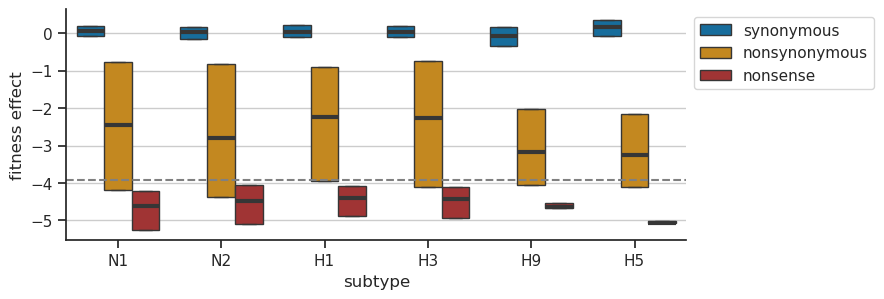

In [27]:
# Get data
count_threshold = 25
data = fitness_df[fitness_df['expected_count'] >= count_threshold].copy()
fitness_lod = np.log(0.5/(count_threshold+0.5))
# data['delta_fitness'] = data['delta_fitness'].clip(lower=np.log(0.5/(count_threshold+0.5)))

# Explode dataframe so that there is one row per mutation per gene
data['gene'] = data['gene'].str.split(';')
data['codon_site'] = data['codon_site'].str.split(';')
data = data.explode(['gene', 'codon_site'])

# Sort dataframe by median delta_fitness of nonsynonymous mutations
nonsynonymous_medians = (
    data[data['mut_class'] == 'nonsynonymous']
    .groupby('gene', as_index=False)['delta_fitness']
    .median()
    .sort_values('delta_fitness')
    .rename(columns={'delta_fitness':'median_nonsyn_fitness'})
)
data = (
    data
    .merge(nonsynonymous_medians)
    .sort_values('median_nonsyn_fitness', ascending=True)
)

# Plot data
plt.figure(figsize=[12,3])
sns.boxplot(
    x='gene', y='delta_fitness', data=data,
    hue='mut_class', hue_order=['synonymous', 'nonsynonymous', 'nonsense'],
    palette=mut_class_colors,
    medianprops={"linewidth": 3}, showfliers=False, whis=(50,50)
)
plt.axhline(fitness_lod, color='gray', linestyle='--')
plt.grid(axis='y')
plt.legend(bbox_to_anchor=(1,1))
plt.ylabel('fitness effect')
sns.despine()
plt.show()

# Plot distributions for different HA and NA subtypes
ha_na_data = data[data['gene'].isin(['HA', 'NA'])].copy()
plt.figure(figsize=[8,3])
sns.boxplot(
    x='subtype', y='delta_fitness', data=ha_na_data,
    hue='mut_class', hue_order=['synonymous', 'nonsynonymous', 'nonsense'],
    palette=mut_class_colors,
    medianprops={"linewidth": 3}, showfliers=False, whis=(50,50)
)
plt.axhline(fitness_lod, color='gray', linestyle='--')
plt.grid(axis='y')
plt.legend(bbox_to_anchor=(1,1))
plt.ylabel('fitness effect')
sns.despine()
plt.show()

Examine the fitness effects of synonymous mutation across the genome.

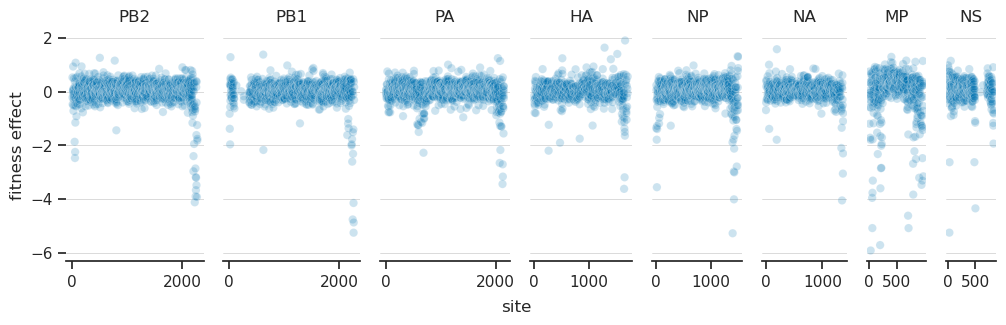

In [28]:
# Get data
count_threshold = 25
mut_classes_to_plot = ['synonymous']
syn_data = nt_fitness_df[
    (nt_fitness_df['subtype'].isin(['all', 'H1', 'N1'])) &
    (nt_fitness_df['mut_class'].isin(mut_classes_to_plot)) &
    (nt_fitness_df['expected_count'] >= count_threshold)
].copy()

# Get width ratios for plotting segments
segments = ['PB2', 'PB1', 'PA', 'HA', 'NP', 'NA', 'MP', 'NS']
width_ratios = []
for segment in segments:
    data = counts_df[counts_df['segment'] == segment]
    width_ratios.append(data['site'].max())

# Plot data
(fig, axs) = plt.subplots(
    ncols=len(segments), sharey=True, figsize=[12, 3],
    gridspec_kw={'width_ratios': width_ratios}
)
for (i, segment) in enumerate(segments):
    data = syn_data[(syn_data['segment'] == segment)]
    sns.scatterplot(
        x='site', y='delta_fitness', data=data, ax=axs[i], alpha=0.2,
        hue='mut_class', palette=mut_class_colors
    )
    axs[i].grid(axis='y', which='both', lw=0.5)
    axs[i].set(title=segment, xlabel='')
    axs[i].get_legend().remove()
    if i > 0:
        axs[i].tick_params(axis='y', which='both', left=False, labelleft=False)
    if segment in ['MP', 'NS']:
        axs[i].set(xticks=[0, 500])
    sns.despine(left=True, ax=axs[i])

axs[0].set(ylabel='fitness effect')
fig.text(0.5, -0.06, 'site', ha='center')
plt.show()

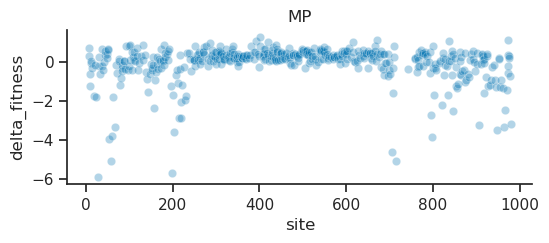

In [29]:
segment = 'MP'
data = syn_data[(syn_data['segment'] == segment)]
plt.figure(figsize=[6,2])
sns.scatterplot(x='site', y='delta_fitness', data=data, alpha=0.3)
plt.title(segment)
sns.despine()
plt.show()

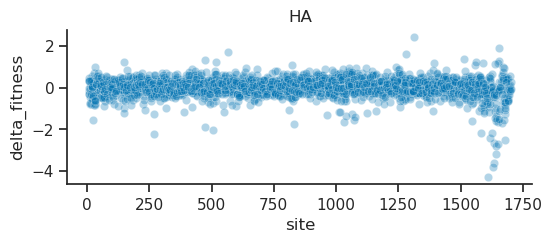

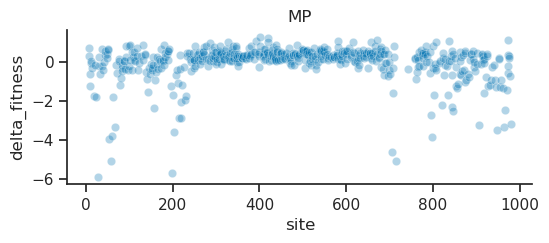

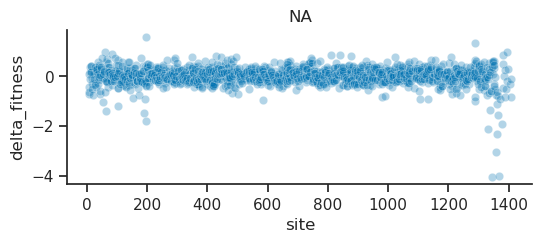

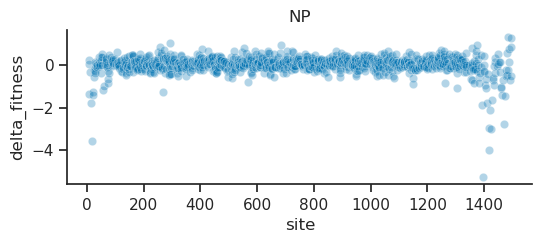

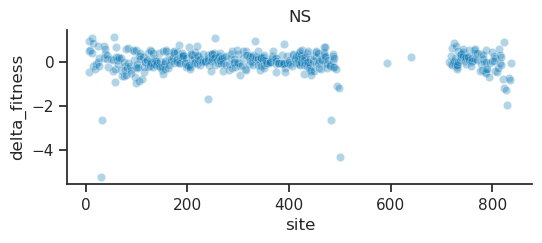

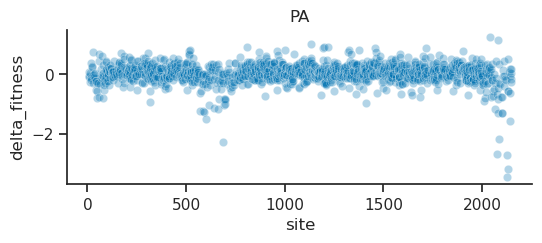

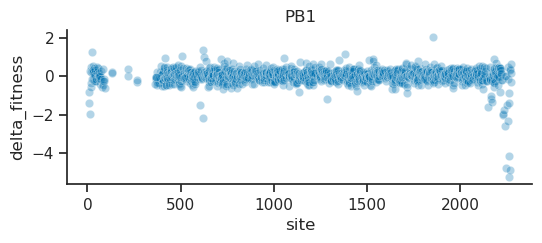

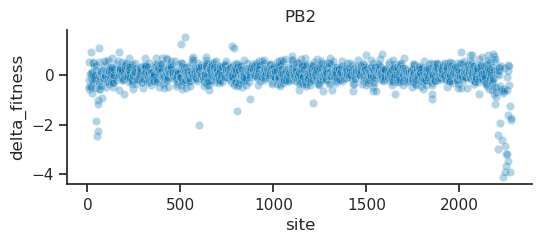

In [30]:
count_threshold = 10
syn_data = nt_fitness_df[
    # (nt_fitness_df['subtype'].isin(['all', 'H5', 'N2'])) &
    (nt_fitness_df['expected_count'] >= count_threshold) &
    (nt_fitness_df['mut_class'] == 'synonymous')
].copy()
for (segment, segment_data) in syn_data.groupby('segment'):
    plt.figure(figsize=[6,2])
    sns.scatterplot(x='site', y='delta_fitness', data=segment_data, alpha=0.3)
    plt.title(segment)
    sns.despine()
    plt.show()

In [31]:
segment_data[segment_data['delta_fitness'] < -2]

,subtype,segment,gene,site,codon_site,wt_nt,mut_class,actual_count,expected_count_gw,expected_count,delta_fitness_gw,delta_fitness
23102,all,PB2,PB2,51,17,C,synonymous,35,260.708161,420.043098,-1.995785,-2.472014
23105,all,PB2,PB2,54,18,G,synonymous,30,291.948916,287.682388,-2.260563,-2.245867
25863,all,PB2,PB2,2208,736,A,synonymous,7,140.075326,145.176817,-2.930840,-2.966488
25866,all,PB2,PB2,2209,737,C,synonymous,8,82.506357,93.243885,-2.278851,-2.400500
25890,all,PB2,PB2,2229,743,A,synonymous,1,37.898682,19.809330,-3.242558,-2.605615
25891,all,PB2,PB2,2232,744,T,synonymous,3,182.729028,214.828238,-3.957974,-4.119401
25899,all,PB2,PB2,2244,748,G,synonymous,16,292.090015,287.822267,-2.875412,-2.860718
25900,all,PB2,PB2,2247,749,A,synonymous,2,177.958636,123.025948,-4.268066,-3.900161
25904,all,PB2,PB2,2250,750,G,synonymous,22,344.831212,541.481404,-2.730989,-3.181716
25906,all,PB2,PB2,2253,751,C,synonymous,4,261.153193,175.933753,-4.062943,-3.668868


Make a fitness dataframe for HA or NA with columns giving alignment numbering

In [56]:
# Get fitness effects for the same mutations at the same sites across homologs
count_threshold = 10
fitness_lod = np.log(0.5/(count_threshold+0.5))
genes = [
    'HA',
    'NA'
]
print('Clipping data to fitness LOD of', fitness_lod, 'and upper limit of 2.0')
homolog_data = (
    fitness_df[
        (fitness_df['gene'].isin(genes)) &
        (fitness_df['expected_count'] >= count_threshold)
    ]
    .assign(codon_site=lambda x: x['codon_site'].astype(int))
    .query('wt_aa != "*"')
    .merge(numbering_df, validate='many_to_one')
    .pivot_table(
        index=['alignment_index', 'wt_aa', 'mut_aa', 'mut_class'],
        columns='subtype', values='delta_fitness'
    )
    .clip(lower=fitness_lod, upper=2)
    .reset_index()
    .rename_axis(None, axis=1)
)
homolog_data.to_csv('../results/homolog_fitness.csv', index=False)
homolog_data[homolog_data['H1'].notnull() & homolog_data['H3'].notnull()]

Clipping data to fitness LOD of -3.044522437723423 and upper limit of 2.0


,alignment_index,wt_aa,mut_aa,mut_class,H1,H3,H5,H9,N1,N2
0,1,M,I,nonsynonymous,-3.044522,-1.960911,-3.044522,-3.044522,-3.044522,-3.044522
1,1,M,K,nonsynonymous,0.393136,-3.044522,NaN,NaN,-2.477310,-3.044522
2,1,M,R,nonsynonymous,-2.164037,-3.044522,NaN,NaN,-1.294881,-1.507356
3,1,M,T,nonsynonymous,-3.044522,-3.044522,-3.044522,NaN,-3.044522,-3.044522
7,2,K,E,nonsynonymous,-0.252699,-1.661857,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
8700,582,I,I,synonymous,-0.096629,-0.071326,0.333469,NaN,NaN,NaN
8702,582,I,M,nonsynonymous,-2.057107,-1.230215,NaN,-3.044522,NaN,NaN
8703,582,I,S,nonsynonymous,-1.832779,-3.044522,NaN,NaN,NaN,NaN
8704,582,I,T,nonsynonymous,-3.044522,-3.044522,-3.044522,-2.070508,NaN,NaN


Compare mutational effects between subtypes.

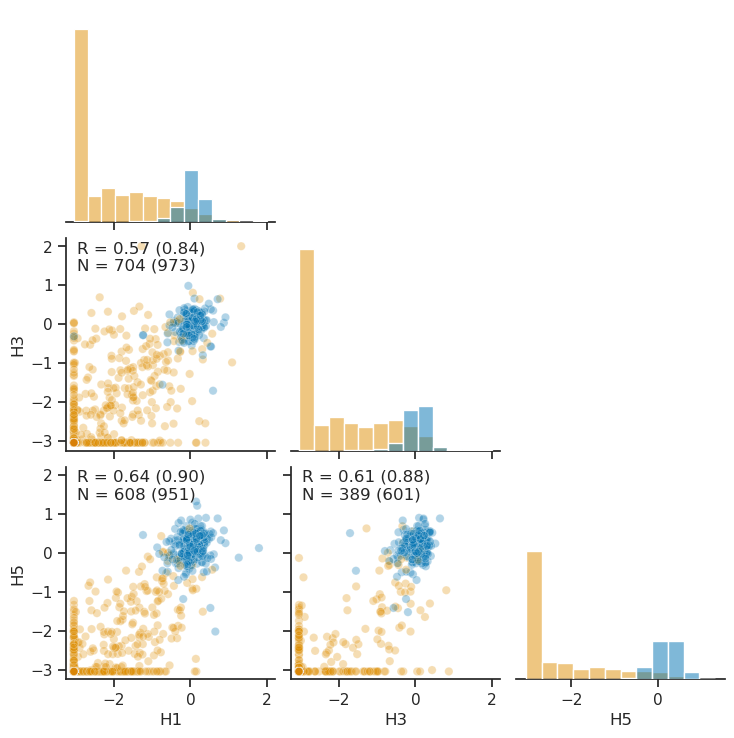

In [58]:
# Get data
homologs = ['H1', 'H3', 'H5']
data = homolog_data[homologs + ['mut_class']].copy()

# Clip delta_fitness values to 2.0
# print('Clipping delta_fitness values to 2.0')
# for homolog in homologs:
#     data[homolog] = data[homolog].clip(upper=2.0)
# data = data.dropna()

# Use seaborn pairplot to plot all pairwise comparisons, only showing lower triangle,
# and hiding the diagonal
g = sns.pairplot(
    data, kind='scatter', plot_kws={'alpha':0.3}, corner=True,
    hue='mut_class', hue_order=['synonymous', 'nonsynonymous'], palette=mut_class_colors,
    diag_kind='hist',
)
global_min = data[homologs].min().min() - 0.2
global_max = data[homologs].max().max() + 0.2
g._legend.remove()

# Annotate plots with correlation coefficients, computing Pearson's R only for nonsynonymous mutations
for i, j in zip(*np.tril_indices_from(g.axes, -1)):
    if i == j:
        continue
    ax = g.axes[i, j]
    ax.set_xlim(global_min, global_max)
    ax.set_ylim(global_min, global_max)
    x_var = g.x_vars[j]
    y_var = g.y_vars[i]
    subset = data[[x_var, y_var]].dropna()
    nonsynonymous_subset = data[data['mut_class'] == 'nonsynonymous'][[x_var, y_var]].dropna()
    r, p = scipy.stats.pearsonr(subset[x_var], subset[y_var])
    r_nonsyn, p_nonsyn = scipy.stats.pearsonr(nonsynonymous_subset[x_var], nonsynonymous_subset[y_var])
    n = len(subset)
    n_nonsyn = len(nonsynonymous_subset)
    ax.annotate(f'R = {r_nonsyn:.2f} ({r:.2f})\nN = {n_nonsyn} ({n})', xy=(0.05, 0.85), xycoords='axes fraction', fontsize=12)

Plot the cumulative distribution of absolute differences.

In [73]:
# Compute differences in effects between homologs
homologs = [
    'H1', 'H3', 'H5',
    # 'N1', 'N2'
]
shift_data = homolog_data.copy()
shift_cols = []
for i, h1 in enumerate(homologs):
    for j, h2 in enumerate(homologs):
        if (i >= j) or (h1[0] != h2[0]):
            continue
        col_name = f'{h1}, {h2}'
        shift_data[col_name] = np.abs(shift_data[h2] - shift_data[h1])
        shift_data[col_name] = shift_data[col_name].clip(upper=4.0)
        shift_cols.append(col_name)
shift_data = (
    shift_data
    .melt(
        id_vars=['alignment_index', 'wt_aa', 'mut_aa', 'mut_class'],
        value_vars=shift_cols, var_name='homolog_pair', value_name='abs_diff'
    )
    .dropna()
)
shift_data.value_counts('homolog_pair')

homolog_pair
H1, H3    973
H1, H5    951
H3, H5    601
Name: count, dtype: int64

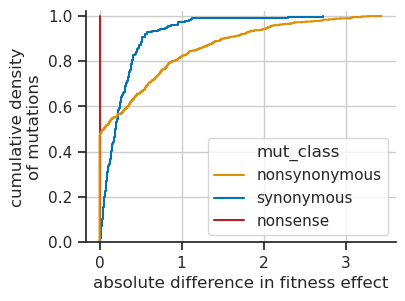

In [74]:
data = shift_data[shift_data['homolog_pair'] == 'H1, H3']
plt.figure(figsize=[4,3])
sns.ecdfplot(x='abs_diff', data=data, hue='mut_class', palette=mut_class_colors)
plt.xlabel('absolute difference in fitness effect')
plt.ylabel('cumulative density\nof mutations')
plt.ylim(0, 1.02)
plt.grid()
sns.despine()
plt.show()

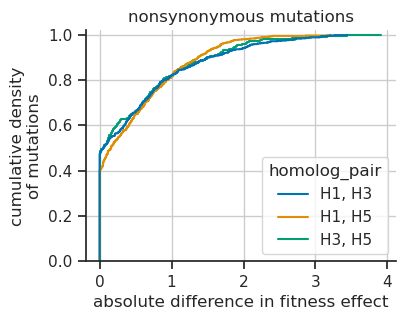

In [75]:
data = shift_data[shift_data['mut_class'] == 'nonsynonymous']
plt.figure(figsize=[4,3])
sns.ecdfplot(x='abs_diff', data=data, hue='homolog_pair')
plt.xlabel('absolute difference in fitness effect')
plt.ylabel('cumulative density\nof mutations')
plt.ylim(0, 1.02)
plt.title('nonsynonymous mutations')
plt.grid()
sns.despine()
plt.show()

Plot data for a single pair of homologs.

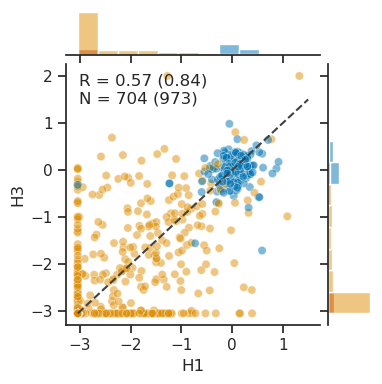

In [78]:
# Get data
(subtype_1, subtype_2) = ('H1', 'H3')
# (subtype_1, subtype_2) = ('N1', 'N2')
data = homolog_data[
    homolog_data[subtype_1].notnull() & homolog_data[subtype_2].notnull()
].copy()
data['diff'] = data[subtype_2] - data[subtype_1]

# Compute R for all mutations or for just nonsynonymous mutations
r = data[subtype_1].corr(data[subtype_2])
n = len(data)
nonsyn_data = data[data['mut_class'] == 'nonsynonymous'].copy()
n_nonsyn = len(nonsyn_data)
r_nonsyn = nonsyn_data[subtype_1].corr(nonsyn_data[subtype_2])

# Plot data
g = sns.JointGrid(data=data, x=subtype_1, y=subtype_2, hue='mut_class', palette=mut_class_colors, height=4)
g.plot_joint(sns.scatterplot, alpha=0.5, legend=False)
g.ax_joint.annotate(f'R = {r_nonsyn:.2f} ({r:.2f})\nN = {n_nonsyn} ({n})', xy=(0.05, 0.85), xycoords='axes fraction', fontsize=12)
g.ax_joint.plot([data[subtype_1].min(), 1.5], [data[subtype_1].min(), 1.5], color='0.25', linestyle='--')
g.plot_marginals(sns.histplot)
plt.show()

In [79]:
data['aas'] = data['wt_aa'] + data['mut_aa']
print(len(data))
data[data['mut_class'] == 'nonsynonymous']['aas'].value_counts().head(20)

973


aas
GV    23
CF    15
CY    15
CS    15
CR    15
NK    14
NS    14
NT    14
ND    14
GR    13
GE    13
PS    12
PL    12
CG    12
PT    12
YC    11
DG    11
YH    11
DN    11
TA    11
Name: count, dtype: int64

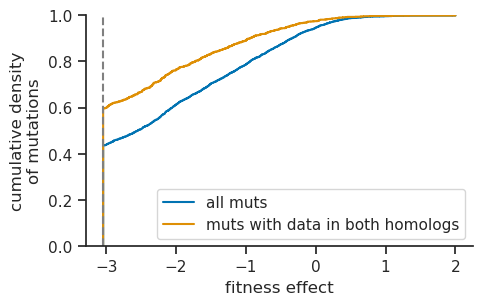

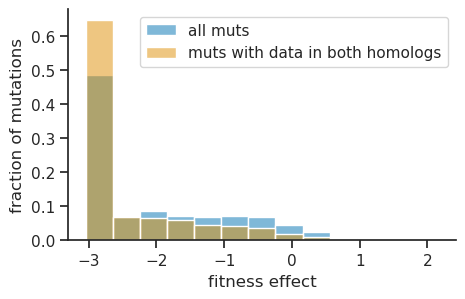

In [90]:
# Get data
homologs = [subtype_1, subtype_2]
all_muts = (
    homolog_data[homolog_data['mut_class'] == 'nonsynonymous'][homologs]
    .melt(var_name='homolog', value_name='delta_fitness')
)
all_homolog_muts = (
    homolog_data[homolog_data['mut_class'] == 'nonsynonymous'][homologs]
    .dropna()
    .melt(var_name='homolog', value_name='delta_fitness')
)

plt.figure(figsize=[5,3])
sns.ecdfplot(data=all_muts, x='delta_fitness', label='all muts')
sns.ecdfplot(data=all_homolog_muts, x='delta_fitness', label='muts with data in both homologs')
min_fitness = all_muts['delta_fitness'].min()
plt.axvline(min_fitness, color='gray', linestyle='--')
plt.xlabel('fitness effect')
plt.ylabel('cumulative density\nof mutations')
plt.legend()
sns.despine()
plt.show()

plt.figure(figsize=[5,3])
bins = np.arange(min_fitness, 2.5, 0.4)
sns.histplot(
    x='delta_fitness', data=all_muts, bins=bins, alpha=0.5,
    label='all muts', stat='probability'
)
sns.histplot(
    x='delta_fitness', data=all_homolog_muts, bins=bins, alpha=0.5,
    label='muts with data in both homologs', stat='probability'
)
plt.xlabel('fitness effect')
plt.ylabel('fraction of mutations')
plt.legend()
sns.despine()
plt.show()

Look for signs of entrenchment

In [39]:
# Slice the above dataframe to just include rows for the H1 subtype
h1_data = numbering_df[numbering_df['subtype'] == 'H1'].copy()

# Change the column name from wt_aa to h1_aa
col_dict = {'wt_aa': 'h1_aa'}
h1_data.rename(columns=col_dict, inplace=True)

# Do the same thing for H3, then merge the two dataframes on the alignment_index
# column
h3_data = numbering_df[numbering_df['subtype'] == 'H3'].copy()
col_dict = {'wt_aa': 'h3_aa'}
h3_data.rename(columns=col_dict, inplace=True)
# Merging h1 and h3 df
cols_to_keep = ['alignment_index', 'h1_aa', 'h3_aa']
h1h3_data = pd.merge(
    h1_data[['alignment_index', 'h1_aa']], h3_data[['alignment_index', 'h3_aa']],
    on='alignment_index', how='inner'
)

# Make a new column that gives the mutation string from H1 to H3
h1h3_data['forward_mut'] = h1h3_data['h1_aa'] + h1h3_data['alignment_index'].astype(str) + h1h3_data['h3_aa']

# Also make a column that gives the mutation string from H3 to H1, calling it 'reverse_mut'
h1h3_data['reverse_mut'] = h1h3_data['h3_aa'] + h1h3_data['alignment_index'].astype(str) + h1h3_data['h1_aa']

# Subset the dataframe to only include rows where the h1_aa and h3_aa are not the same
h1h3_data = h1h3_data[h1h3_data['h1_aa'] != h1h3_data['h3_aa']].copy()

h1h3_data

,alignment_index,h1_aa,h3_aa,forward_mut,reverse_mut
2,3,A,T,A3T,T3A
3,4,N,I,N4I,I4N
4,5,L,I,L5I,I5L
5,6,L,A,L6A,A6L
6,7,V,L,V7L,L7V
...,...,...,...,...,...
547,573,N,R,N573R,R573N
549,575,S,N,S575N,N575S
550,576,L,I,L576I,I576L
551,577,Q,R,Q577R,R577Q


In [40]:
count_threshold = 10
fitness_lod = np.log(0.5/(count_threshold+0.5))
ha_data = (
    fitness_df[
        (fitness_df['gene'] == 'HA') &
        (fitness_df['expected_count'] >= count_threshold)
    ]
    .assign(codon_site=lambda x: x['codon_site'].astype(int))
    .merge(numbering_df, validate='many_to_one')
    .assign(aa_mut_alignment=lambda x: x['wt_aa'] + x['alignment_index'].astype(str) + x['mut_aa'])
    .assign(delta_fitness = lambda x: x['delta_fitness'].clip(lower=fitness_lod))
)

forward_mut_data = ha_data[
    (ha_data['subtype'] == 'H1') &
    (ha_data['aa_mut_alignment'].isin(h1h3_data['forward_mut']))
]

reverse_mut_data = ha_data[
    (ha_data['subtype'] == 'H3') &
    (ha_data['aa_mut_alignment'].isin(h1h3_data['reverse_mut']))
]

cols = ['subtype', 'alignment_index', 'aa_mut_alignment', 'delta_fitness']
both_mut_data = (
    pd.concat([forward_mut_data[cols], reverse_mut_data[cols]])
    .sort_values(['alignment_index', 'subtype'])
    .pivot(index='alignment_index', columns='subtype', values='delta_fitness')
    .dropna()
    .reset_index()
    .rename_axis(None, axis=1)
)
print(len(both_mut_data))
both_mut_data.head()

49


,alignment_index,H1,H3
0,3,-0.375386,-0.172677
1,5,-0.102558,-1.254813
2,10,-0.963669,-0.141526
3,26,-0.952561,-0.267855
4,31,-2.573591,0.350366


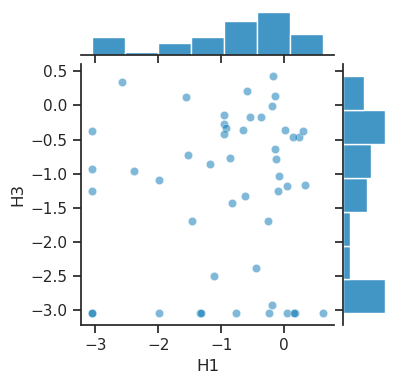

In [41]:
# Plot data
g = sns.JointGrid(data=both_mut_data, x='H1', y='H3', height=4)
g.plot_joint(sns.scatterplot, alpha=0.5, legend=False)
g.plot_marginals(sns.histplot)
plt.show()

Compare fitness effects to DMS data for HA.

In [42]:
# Read in numbering scheme
ha_numbering_data = pd.read_csv('../results/dms_data/Yu_HA/numbering_map.csv')
del ha_numbering_data['region']
del ha_numbering_data['rbs_region']

# Get fitness data
count_threshold = 10
fitness_lod = np.log(0.5/(count_threshold+0.5))
fitness_data = fitness_df[
    (fitness_df['expected_count'] >= count_threshold) &
    (fitness_df['gene'] == 'HA') &
    (fitness_df['subtype'] == 'H3')
].copy()
fitness_data['codon_site'] = fitness_data['codon_site'].astype(int)

# Read in DMS data and merge with numbering data and fitness data
f = '../data/dms_data/Yu_HA/Phenotypes.csv'
ha_dms_data = (
    pd.read_csv(f)
    .rename(
        columns={
            'MDCKSIAT1 cell entry' : 'cell_entry',
            'sera escape' : 'sera_escape',
            'pH stability' : 'pH_stability',
            'wildtype' : 'wt_aa',
            'mutant' : 'mut_aa',
            'nt changes to codon' : 'n_nt_changes'
        }
    )
    .merge(ha_numbering_data, on='sequential_site', validate='many_to_one')
    .rename(columns={'tree_reference_site' : 'codon_site'})
    .merge(fitness_data, on=['codon_site', 'wt_aa', 'mut_aa'], how='inner')
    .sort_values('codon_site')
)

data = ha_dms_data[ha_dms_data['cell_entry'].notnull() & ha_dms_data['delta_fitness'].notnull()]
print('N muts with data:', len(data))
print('N sites with data:', data['codon_site'].nunique())
data.head()

N muts with data: 2506
N sites with data: 504


,site,wt_aa,mut_aa,sera_escape,cell_entry,pH_stability,sequential_site,region,n_nt_changes,codon_site,reference_site,sequential_wt,subtype,segment,gene,aa_mut,mut_class,actual_count,expected_count_gw,expected_count,delta_fitness_gw,delta_fitness
1,1,Q,K,0.04918,-0.1115,0.001008,1,HA1,1,17,1,Q,H3,HA,HA,Q17K,nonsynonymous,55,63.685171,41.032524,-0.145389,0.289906
0,1,Q,H,0.03837,-0.2349,-0.004620,1,HA1,1,17,1,Q,H3,HA,HA,Q17H,nonsynonymous,6,29.339585,17.834674,-1.524034,-1.036992
3,1,Q,R,-0.19230,-0.8861,0.012610,1,HA1,1,17,1,Q,H3,HA,HA,Q17R,nonsynonymous,17,108.058060,44.263436,-1.825084,-0.939191
2,1,Q,L,-0.16660,-1.5680,0.033410,1,HA1,1,17,1,Q,H3,HA,HA,Q17L,nonsynonymous,2,17.494230,11.649863,-1.973760,-1.581027
4,1,Q,Q,0.00000,0.0000,0.000000,1,HA1,0,17,1,Q,H3,HA,HA,Q17Q,synonymous,73,109.166994,81.377565,-0.400163,-0.107940


Plot the correlation between fitness effects and DMS phenotypes.

cell_entry
r all: 0.799758805063673
r nonsyn: 0.7535669198317985


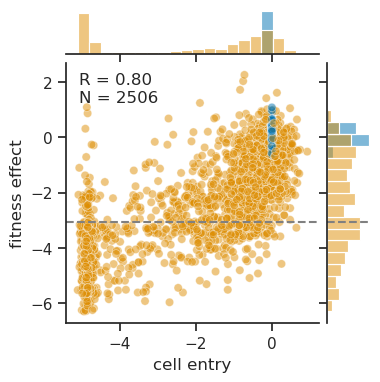

pH_stability
r all: 0.4061059288021262
r nonsyn: 0.34054520916101017


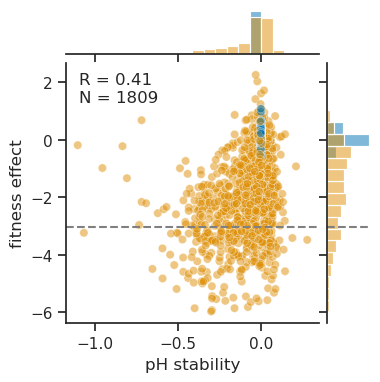

sera_escape
r all: 0.0570735791692192
r nonsyn: 0.007194851240708936


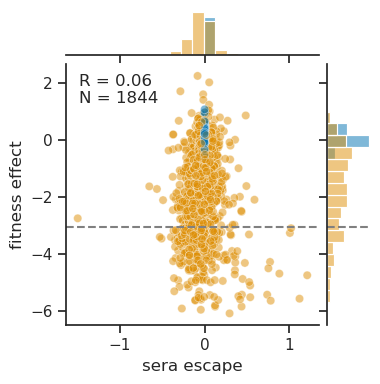

In [43]:
dms_metrics = ['cell_entry', 'pH_stability', 'sera_escape']
for dms_metric in dms_metrics:

    data = ha_dms_data[(ha_dms_data[dms_metric].notnull()) & (ha_dms_data['delta_fitness'].notnull())]
    r = data[dms_metric].corr(data['delta_fitness'])
    nonsyn_data = data[data['mut_class'] == 'nonsynonymous']
    r_nonsyn = nonsyn_data[dms_metric].corr(nonsyn_data['delta_fitness'])
    print(dms_metric)
    print('r all:', r)
    print('r nonsyn:', r_nonsyn)

    g = sns.JointGrid(data=data, x=dms_metric, y='delta_fitness', hue='mut_class', palette=mut_class_colors, height=4)
    g.plot_joint(sns.scatterplot, alpha=0.5, legend=False)
    g.ax_joint.annotate(f'R = {r:.2f}\nN = {len(data)}', xy=(0.05, 0.85), xycoords='axes fraction', fontsize=12)
    g.ax_joint.axhline(y=fitness_lod, color='gray', linestyle='--')
    g.ax_joint.set(xlabel=dms_metric.replace('_', ' '), ylabel='fitness effect')
    
    g.plot_marginals(sns.histplot, bins=20)
    g.ax_marg_y.axhline(y=fitness_lod, color='gray', linestyle='--')
    
    plt.show()

In [44]:
dms_metric = 'sera_escape'
data = ha_dms_data[
    (ha_dms_data[dms_metric].notnull()) &
    (ha_dms_data[dms_metric] > 0.4) &
    (ha_dms_data['delta_fitness'] <-4) &
    (ha_dms_data['delta_fitness'].notnull())
]
data

,site,wt_aa,mut_aa,sera_escape,cell_entry,pH_stability,sequential_site,region,n_nt_changes,codon_site,reference_site,sequential_wt,subtype,segment,gene,aa_mut,mut_class,actual_count,expected_count_gw,expected_count,delta_fitness_gw,delta_fitness
446,98,Y,C,0.4407,-4.809,-0.2930,98,HA1,1,114,98,Y,H3,HA,HA,Y114C,nonsynonymous,0,108.095713,114.543815,-5.380779,-5.438460
625,136,S,I,0.4755,-4.894,-0.1968,136,epitope-A,1,152,136,S,H3,HA,HA,S152I,nonsynonymous,0,41.239017,37.115715,-4.424584,-4.320569
624,136,S,G,0.5381,-4.753,-0.2208,136,epitope-A,1,152,136,S,H3,HA,HA,S152G,nonsynonymous,0,108.095713,82.858141,-5.380779,-5.116293
851,185,P,L,0.4492,-4.832,-0.3372,185,HA1,1,201,185,P,H3,HA,HA,P201L,nonsynonymous,1,137.822063,197.792182,-4.524120,-4.884277
885,193,S,P,0.5267,-4.918,-0.3525,193,epitope-B,1,209,193,S,H3,HA,HA,S209P,nonsynonymous,0,58.786486,73.269164,-4.775529,-4.994088
894,195,F,L,0.8835,-4.845,-0.2635,195,epitope-B,1,211,195,F,H3,HA,HA,F211L,nonsynonymous,0,66.057073,54.256218,-4.891207,-4.696038
1307,281,C,Y,0.5389,-5.101,NaN,281,HA1,1,297,281,C,H3,HA,HA,C297Y,nonsynonymous,0,225.414243,125.287071,-6.113303,-5.527738
1509,324,P,S,0.4366,-4.655,-0.1587,324,HA1,1,340,324,P,H3,HA,HA,P340S,nonsynonymous,0,137.729321,174.185059,-5.622061,-5.856132
1569,336,A,T,1.2130,-4.866,-0.1241,336,HA2,1,352,336,A,H3,HA,HA,A352T,nonsynonymous,1,225.401751,173.619018,-5.014635,-4.754274
1702,367,L,P,1.1220,-4.876,NaN,367,HA2,1,383,367,L,H3,HA,HA,L383P,nonsynonymous,0,108.502880,131.913706,-5.384521,-5.579078


Examine whether a linear combination of DMS phenotypes results in a better correlation with fitness effects.

# muts 1808
pH_weight = 0


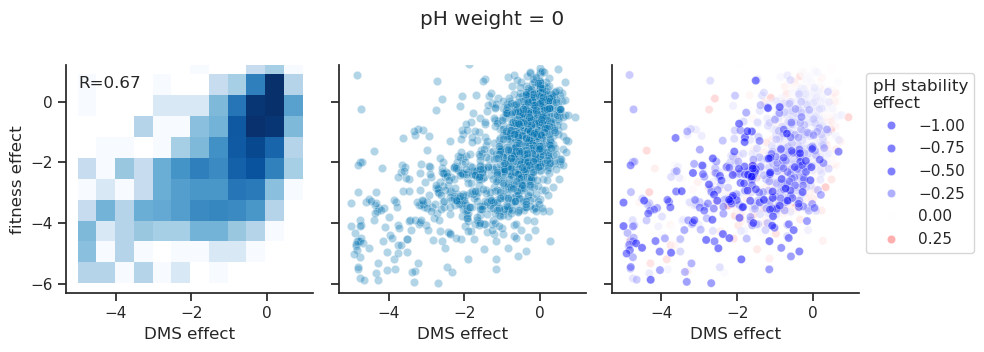

pH_weight = 1


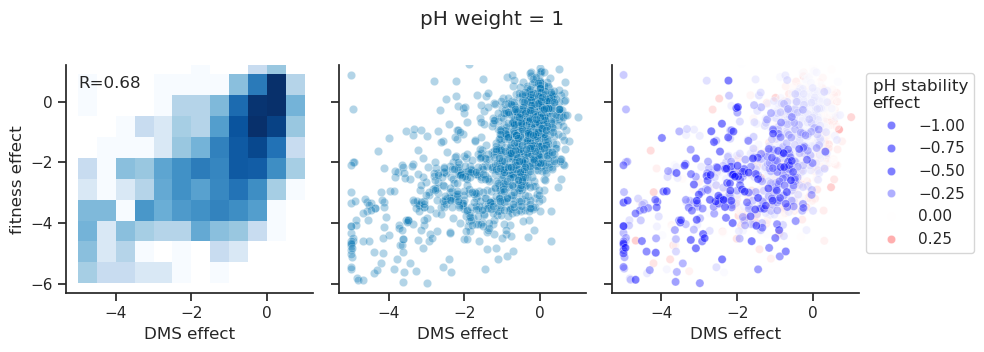

pH_weight = 2


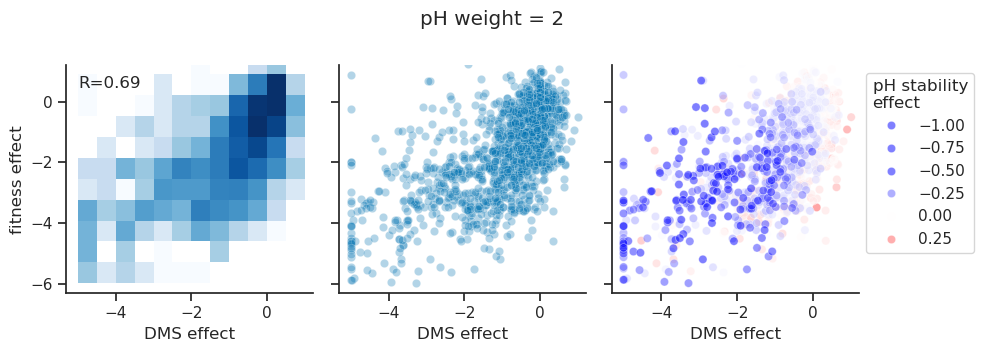

pH_weight = 3


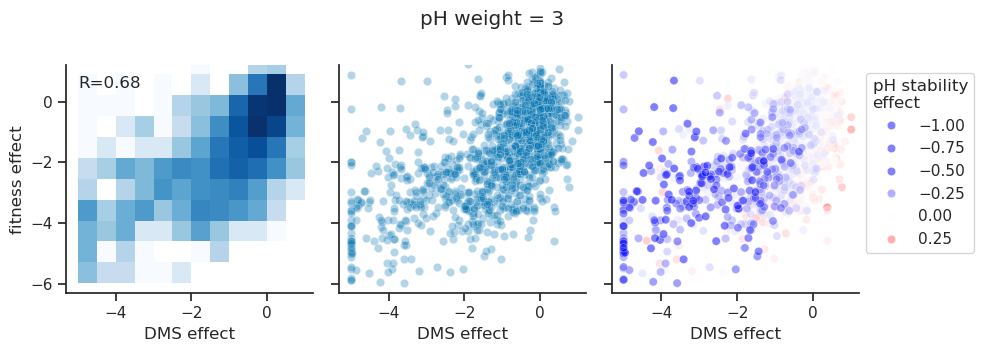

pH_weight = 4


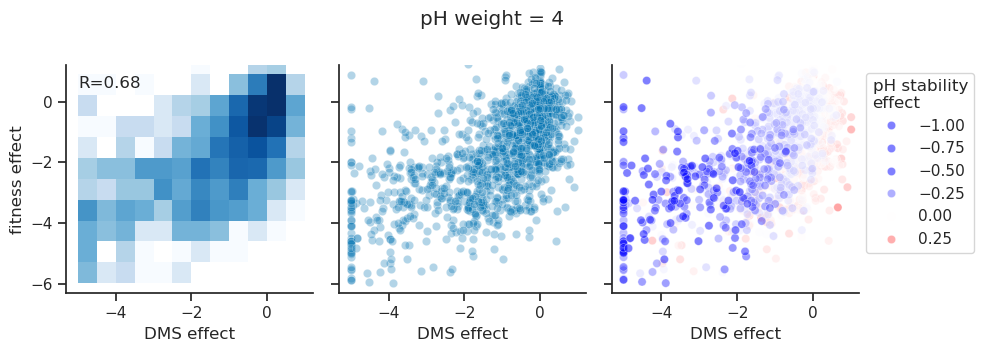

pH_weight = 5


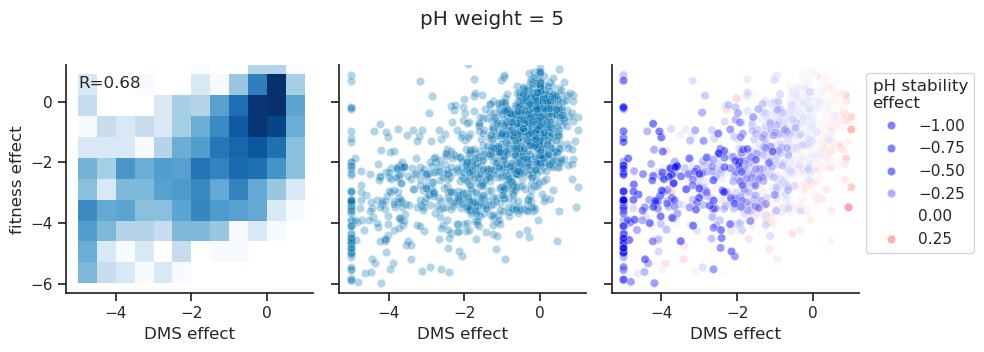

pH_weight = 6


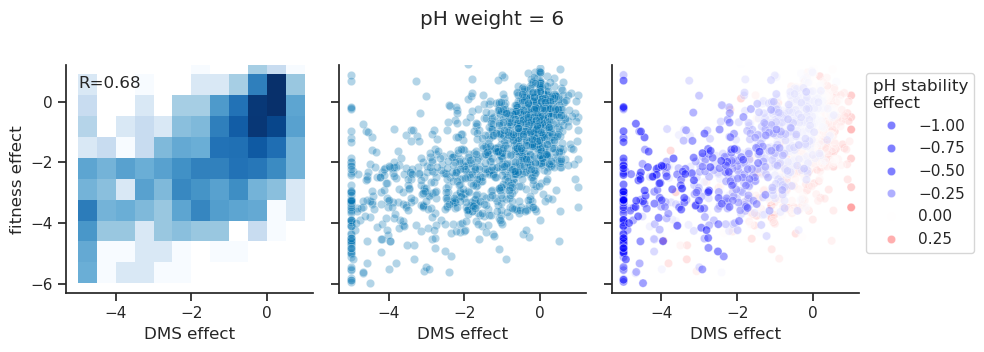

pH_weight = 8


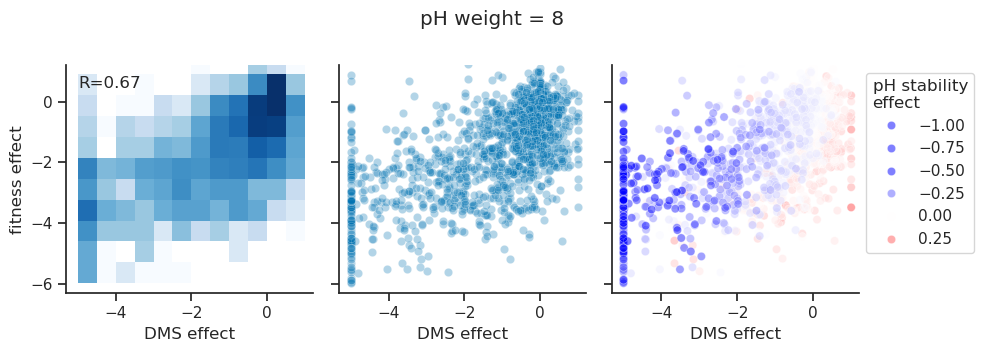

pH_weight = 10


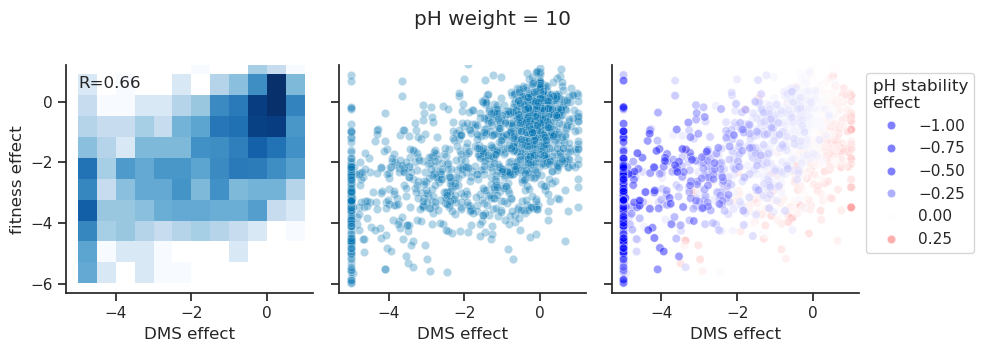

pH_weight = 20


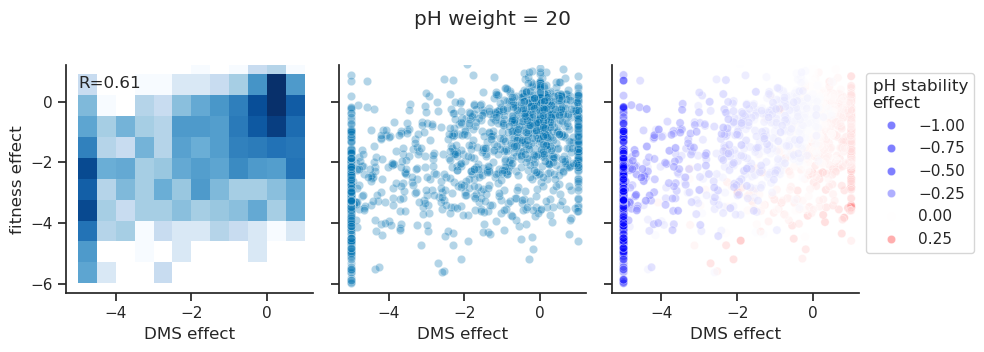

In [51]:
# Get data
data = ha_dms_data[
    # (ha_dms_data['mut_class'] == 'nonsynonymous') &
    (ha_dms_data['delta_fitness'].notnull()) &
    (ha_dms_data['cell_entry'].notnull()) &
    (ha_dms_data['pH_stability'].notnull())
].copy()
print('# muts', len(data))

# Clip data
dms_effect_lower_bound = -5
# data['delta_fitness'] = data['delta_fitness'].clip(lower=-3, upper=1)
# data['cell_entry'] = data['cell_entry'].clip(lower=dms_effect_lower_bound, upper=1)
# data['pH_stability'] = data['pH_stability'].clip(lower=-0.5)

# Sort data by pH stability
data.sort_values('pH_stability', inplace=True, ascending=False)

# Define which meteric to analyze
dms_metric = 'combi'
pH_weights = [0, 1, 2, 3, 4, 5, 6, 8, 10, 20]
# pH_weights = [4]
corr_dict = defaultdict(list)
for pH_weight in pH_weights:

    # Compute new metric
    data['combi'] = (data['cell_entry']) + (pH_weight * data['pH_stability'])
    data['combi'] = data['combi'].clip(lower=dms_effect_lower_bound, upper=1)

    # Compute correlation
    r = data[dms_metric].corr(data['delta_fitness'])
    print(f'pH_weight = {pH_weight}')
    corr_dict['pH_weight'].append(pH_weight)
    corr_dict['r'].append(r)

    # Plot data
    (fig, axs) = plt.subplots(ncols=3, figsize=(10,3.5), sharey=True, sharex=True)
    axs[0].hist2d(
        data[dms_metric], data['delta_fitness'], bins=12, cmap='Blues',
        norm='log', vmin=1, vmax=100
    )
    axs[0].set(ylim=(-6.3,1.2), xlim=(dms_effect_lower_bound-0.3,1.2), ylabel='fitness effect')
    axs[0].annotate(f'R={r:.2f}', xy=(0.05, 0.9), xycoords='axes fraction')
    sns.scatterplot(
        x=dms_metric, y='delta_fitness', data=data, alpha=0.3, ax=axs[1]
    )
    sns.scatterplot(
        x=dms_metric, y='delta_fitness', data=data, alpha=0.5, ax=axs[2],
        hue='pH_stability', palette='bwr', hue_norm=(-0.4, 0.4)
    )
    for i in [0, 1, 2]:
        axs[i].set(xlabel='DMS effect')
    axs[2].legend(bbox_to_anchor=(1,1), title='pH stability\neffect')
    plt.suptitle(f'pH weight = {pH_weight}', y=1)
    sns.despine()
    plt.tight_layout()
    plt.show()

Compare fitness effects to DMS data for NP.

In [52]:
# Get fitness data
count_threshold = 25
fitness_lod = np.log(0.5/(count_threshold+0.5))
fitness_data = fitness_df[
    (fitness_df['gene'] == 'NP') &
    (fitness_df['expected_count'] >= count_threshold) &
    (fitness_df['subtype'] == 'all')
].copy()
fitness_data['codon_site'] = fitness_data['codon_site'].astype(int)

# Read in data and merge with fitness data. The sites are indexed in the exact same way.
np_dms_data = (
    pd.read_csv('../results/dms_data/Bloom_NP/processed_dms_data.csv')
    .rename(columns={'site':'codon_site'})
    .merge(fitness_data, on=['codon_site', 'wt_aa', 'mut_aa'], how='inner')
    .sort_values('codon_site')
)

print(len(np_dms_data))
np_dms_data

2235


,codon_site,wt_aa,mut_aa,preference,wt_preference,dms_effect,subtype,segment,gene,aa_mut,mut_class,actual_count,expected_count_gw,expected_count,delta_fitness_gw,delta_fitness
701,1,M,I,0.023434,0.391903,-2.816809,all,NP,NP,M1I,nonsynonymous,0,344.843419,280.258826,-6.537687,-6.330643
1845,1,M,T,0.032492,0.391903,-2.490014,all,NP,NP,M1T,nonsynonymous,0,140.589400,98.020302,-5.642541,-5.283410
871,1,M,K,0.038531,0.391903,-2.319554,all,NP,NP,M1K,nonsynonymous,0,23.987520,30.577082,-3.891311,-4.129618
1846,2,A,T,0.004529,0.753436,-5.114244,all,NP,NP,A2T,nonsynonymous,8,291.386249,348.754772,-3.536298,-3.715735
1983,2,A,V,0.080349,0.753436,-2.238261,all,NP,NP,A2V,nonsynonymous,66,178.159868,329.840440,-0.988282,-1.602922
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1044,498,N,K,0.276824,0.088315,1.142474,all,NP,NP,N498K,nonsynonymous,16,38.327400,34.488234,-0.855766,-0.751651
1372,498,N,N,0.088315,0.088315,0.000000,all,NP,NP,N498N,synonymous,88,128.726884,147.847127,-0.378567,-0.516552
870,498,N,I,0.073817,0.088315,-0.179316,all,NP,NP,N498I,nonsynonymous,17,20.705390,26.105767,-0.192055,-0.418927
248,498,N,D,0.001553,0.088315,-4.040906,all,NP,NP,N498D,nonsynonymous,4,127.892699,72.076988,-3.351016,-2.780570


Plot the correlation between fitness effects and DMS effects.

r all: 0.6925409555081208
r nonsyn: 0.4662648382278852


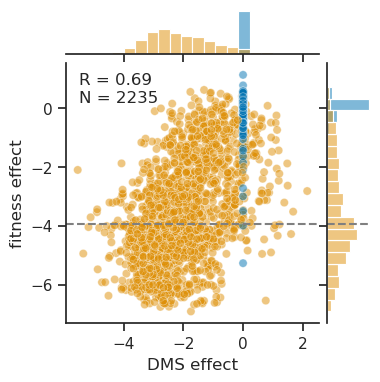

In [54]:
r = np_dms_data['dms_effect'].corr(np_dms_data['delta_fitness'])
nonsyn_data = np_dms_data[np_dms_data['mut_class'] == 'nonsynonymous']
r_nonsyn = nonsyn_data['dms_effect'].corr(nonsyn_data['delta_fitness'])
print('r all:', r)
print('r nonsyn:', r_nonsyn)

g = sns.JointGrid(data=np_dms_data, x='dms_effect', y='delta_fitness', hue='mut_class', palette=mut_class_colors, height=4)
g.plot_joint(sns.scatterplot, alpha=0.5, legend=False)
g.ax_joint.annotate(f'R = {r:.2f}\nN = {len(np_dms_data)}', xy=(0.05, 0.85), xycoords='axes fraction', fontsize=12)
g.ax_joint.axhline(y=fitness_lod, color='gray', linestyle='--')
g.ax_joint.set(xlabel='DMS effect', ylabel='fitness effect')

g.plot_marginals(sns.histplot, bins=20)
g.ax_marg_y.axhline(y=fitness_lod, color='gray', linestyle='--')

# plt.title('NP (Bloom, 2014)')
plt.show()

Compare fitness effects to DMS data for PB2.

In [55]:
# Get fitness data
count_threshold = 25
fitness_lod = np.log(0.5/(count_threshold+0.5))
fitness_data = fitness_df[
    (fitness_df['gene'] == 'PB2') &
    (fitness_df['expected_count'] >= count_threshold) &
    (fitness_df['subtype'] == 'all')
].copy()
fitness_data['codon_site'] = fitness_data['codon_site'].astype(int)

# Read in the DMS data and merge with the fitness data
pb2_dms_data = (
    pd.read_csv('../data/dms_data/Soh_PB2/elife-45079-fig2-data1-v1.csv')
    .rename(columns={
        'site':'codon_site',
        'wildtype' : 'wt_aa', 
        'mutation' : 'mut_aa',
    })
    .merge(fitness_data, on=['codon_site', 'wt_aa', 'mut_aa'], how='inner')
    .sort_values('codon_site')
)

pb2_dms_data

,codon_site,wt_aa,mut_aa,prefA549,prefCCL141,log2prefA549,log2prefCCL141,effectA549,effectCCL141,log2effectA549,log2effectCCL141,mutdiffsel,Known human adaptive,Experimentally adaptive in,subtype,segment,gene,aa_mut,mut_class,actual_count,expected_count_gw,expected_count,delta_fitness_gw,delta_fitness
2730,1,M,T,0.037434,0.052167,-4.739489,-4.260707,0.076396,0.144040,-3.710360,-2.795457,-0.741288,No,NaN,all,PB2,PB2,M1T,nonsynonymous,0,140.872669,91.969550,-5.644547,-5.220027
997,1,M,I,0.051935,0.048641,-4.267144,-4.361682,0.105989,0.134303,-3.238015,-2.896432,0.077020,No,NaN,all,PB2,PB2,M1I,nonsynonymous,10,345.538234,255.731331,-3.495174,-3.194705
692,2,E,G,0.028171,0.012344,-5.149633,-6.340091,0.152174,0.079186,-2.716206,-3.658605,2.084471,No,NaN,all,PB2,PB2,E2G,nonsynonymous,12,139.721051,206.702469,-2.417491,-2.807968
385,2,E,E,0.185125,0.155881,-2.433427,-2.681487,1.000000,1.000000,0.000000,0.000000,NaN,No,NaN,all,PB2,PB2,E2E,synonymous,228,220.074412,214.494117,0.035301,0.060926
225,2,E,D,0.050450,0.051871,-4.308996,-4.268940,0.272519,0.332758,-1.875570,-1.587454,0.985515,No,NaN,all,PB2,PB2,E2D,nonsynonymous,21,46.010768,38.096479,-0.771631,-0.585108
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1261,758,I,I,0.207929,0.304852,-2.265838,-1.713819,1.000000,1.000000,0.000000,0.000000,NaN,No,NaN,all,PB2,PB2,I758I,synonymous,51,260.819300,174.691076,-1.624161,-1.224295
1507,759,N,K,0.156513,0.253609,-2.675648,-1.979323,0.688408,0.783905,-0.538664,-0.351249,-0.286214,No,NaN,all,PB2,PB2,N759K,nonsynonymous,35,41.821327,31.286784,-0.175758,0.110482
2053,759,N,N,0.227355,0.323520,-2.136984,-1.628074,1.000000,1.000000,0.000000,0.000000,NaN,No,NaN,all,PB2,PB2,N759N,synonymous,25,140.737382,151.346765,-1.711764,-1.784193
2729,759,N,S,0.021941,0.026562,-5.510203,-5.234506,0.096507,0.082102,-3.373219,-3.606432,0.286220,No,NaN,all,PB2,PB2,N759S,nonsynonymous,5,139.929786,146.826684,-3.239960,-3.287904


Plot the correlation between fitness effects and DMS effects.

log2effectA549
r all: 0.7444094890839031
r nonsyn: 0.6085561242773723


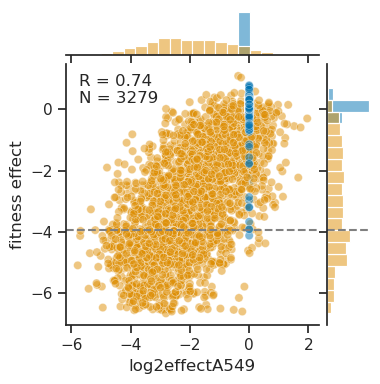

log2effectCCL141
r all: 0.7230990903570607
r nonsyn: 0.6043771664162251


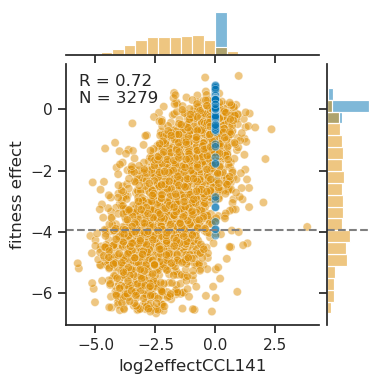

In [128]:
dms_metrics = ['log2effectA549', 'log2effectCCL141']
for dms_metric in dms_metrics:

    data = pb2_dms_data[(pb2_dms_data[dms_metric].notnull()) & (pb2_dms_data['delta_fitness'].notnull())]
    r = data[dms_metric].corr(data['delta_fitness'])
    nonsyn_data = data[data['mut_class'] == 'nonsynonymous']
    r_nonsyn = nonsyn_data[dms_metric].corr(nonsyn_data['delta_fitness'])
    print(dms_metric)
    print('r all:', r)
    print('r nonsyn:', r_nonsyn)

    g = sns.JointGrid(data=data, x=dms_metric, y='delta_fitness', hue='mut_class', palette=mut_class_colors, height=4)
    g.plot_joint(sns.scatterplot, alpha=0.5, legend=False)
    g.ax_joint.annotate(f'R = {r:.2f}\nN = {len(data)}', xy=(0.05, 0.85), xycoords='axes fraction', fontsize=12)
    g.ax_joint.axhline(y=fitness_lod, color='gray', linestyle='--')
    g.ax_joint.set(xlabel=dms_metric.replace('_', ' '), ylabel='fitness effect')
    
    g.plot_marginals(sns.histplot, bins=20)
    g.ax_marg_y.axhline(y=fitness_lod, color='gray', linestyle='--')
    
    plt.show()

For the tree for a given segment and subtype, we compute:
* $c_{a,m}$: actual counts of mutation $m$
* $b_m$: the sum of branch lengths over all branches where $m$ was possible
* $l$: segment length

We compute a mutation's evolutionary opportunity as:

$o_m = \frac{b_m}{l}$

This variable quantifies the average number of mutations per site for all branches where $m$ was possible.

We compute mutation rates as:

$r_{a,m} = \frac{c_{a,m}}{o_m}$

We only analyze mutations with evolutionary opporunities of >10, which allows us to resolve rates across about two orders of magnitude.
Thus, our lower limit of detection is 1/10.
We clip all rates at this lower bound.

Next, we can compute fitness effects using two approaches.

First approach:
For each mutation type, we can compute expected rates $r_{e,m}$ as the average rate of all synonymous mutations for that mutation type.

We can then compute fitness effects as:

$\Delta f_m = \frac{r_{a,m}}{r_{e,m}}$

We only analyze effects for mutations with expected rates that are >1, which is 10-fold higher than the lower limit of detection of rates, so that we have the power to detect deleterious effects.

Second approach:
Alternatively, we can compute expected rates using a neutral model. We could train a neutral model as follows.

For all synonymous mutations for a given mutation type, predict $c_{a,m}$ given $o_m$:

$y_m = o_m \times \beta_0 \times \beta_{\text{motif}}$

Where we minimize the MSE between $y_m$ and $c_{a,m}$. We could add a pseudocount as before.

Then, we can compute fitness effects as before based on the actual counts vs. expected counts from the model:

$\Delta f_m = \frac{c_{a,m}}{y_m}$

In doing the second approach, we wouldn't necessasrily have to exclude mutations with low evolutionary opportunity. This may help detect mutations with large beneficial fitness effects.

R for all mutations 0.6925409555081209
R for nonsynonymous mutations 0.4662648382278854


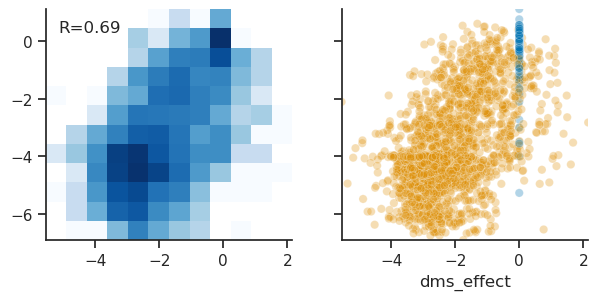

In [ ]:
# Plot data
(fig, axs) = plt.subplots(ncols=2, figsize=(7,3), sharey=True, sharex=True)
axs[0].hist2d(
    np_dms_data['dms_effect'], np_dms_data['delta_fitness'], bins=12, cmap='Blues',
    norm='log', vmin=1, vmax=100
)
r = np_dms_data['dms_effect'].corr(np_dms_data['delta_fitness'])
print('R for all mutations', r)
nonsyn_data = np_dms_data[np_dms_data['mut_class'] == 'nonsynonymous']
r_nonsyn = nonsyn_data['dms_effect'].corr(nonsyn_data['delta_fitness'])
print('R for nonsynonymous mutations', r_nonsyn)
# axs[0].set(ylim=(-3.2,1.2), xlim=(dms_effect_lower_bound-0.3,1.1), xlabel='DMS effect', ylabel='delta fitness')
axs[0].annotate(f'R={r:.2f}', xy=(0.05, 0.9), xycoords='axes fraction')
sns.scatterplot(
    x='dms_effect', y='delta_fitness', data=np_dms_data, alpha=0.3,
    hue='mut_class', palette=mut_class_colors, ax=axs[1]
)
axs[1].get_legend().remove()
sns.despine()
plt.show()

N muts 974
R for all data 0.8355243579702405
R for nonsynonymous mutations 0.5715537557251957


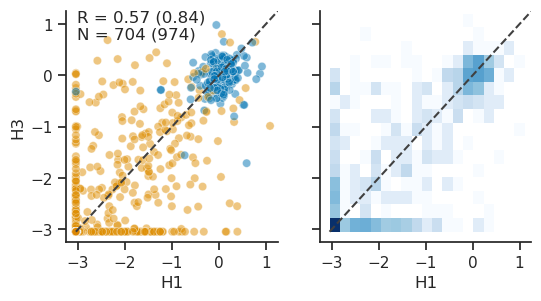

In [ ]:
(subtype_1, subtype_2) = ('H1', 'H3')
# (subtype_1, subtype_2) = ('N1', 'N2')
data = homolog_data[
    # (homolog_data['H1'].notnull()) &
    # (homolog_data['H3'].notnull()) &
    # (homolog_data['H5'].notnull()) &
    homolog_data[subtype_1].notnull() & homolog_data[subtype_2].notnull()
].copy()
data['diff'] = data[subtype_2] - data[subtype_1]
print('N muts', len(data))

# Report R for all data
r = data[subtype_1].corr(data[subtype_2])
print('R for all data', r)

# Report R for nonsynonymous mutations
nonsyn_data = data[data['mut_class'] == 'nonsynonymous'].copy()
r_nonsyn = nonsyn_data[subtype_1].corr(nonsyn_data[subtype_2])
print('R for nonsynonymous mutations', r_nonsyn)

# Plot data
(fig, axs) = plt.subplots(ncols=2, figsize=[6,3], sharex=True, sharey=True)
sns.scatterplot(
    x=subtype_1, y=subtype_2, data=data, hue='mut_class', palette=mut_class_colors,
    alpha=0.5, ax=axs[0]
)
axs[0].get_legend().remove()
n = len(data)
n_nonsyn = len(nonsyn_data)
axs[0].annotate(
    f'R = {r_nonsyn:.2f} ({r:.2f})\nN = {n_nonsyn} ({n})', xy=(0.05, 0.88), xycoords='axes fraction', fontsize=12
)

h = axs[1].hist2d(data[subtype_1], data[subtype_2], bins=20, cmap='Blues', norm='log')
# fig.colorbar(h[3], ax=axs[1])

# Plot y=x line
for i in [0, 1]:
    axs[i].plot([data[subtype_1].min(), 1.5], [data[subtype_1].min(), 1.5], color='0.25', linestyle='--')


ticks = range(round(data[subtype_1].min()), 2, 1)
axs[0].set(
    xticks=ticks, yticks=ticks,
    xlim=(ticks[0]-0.25, ticks[-1]+0.25), ylim=(ticks[0]-0.25, ticks[-1]+0.25)
)
axs[1].set(xlabel=subtype_1)
sns.despine()
plt.show()

In [ ]:
fitness_df[
    (fitness_df['gene'] == 'HA') &
    (fitness_df['aa_mut'] == 'P199Q') &
    (fitness_df['subtype'] == 'H1')
]

,subtype,segment,gene,codon_site,wt_aa,mut_aa,aa_mut,mut_class,actual_count,expected_count_gw,expected_count,delta_fitness_gw,delta_fitness
4374,H1,HA,HA,199,P,Q,P199Q,nonsynonymous,18,63.694249,39.906723,-1.244143,-0.781225


In [ ]:
fitness_df[
    (fitness_df['gene'] == 'HA') &
    (fitness_df['aa_mut'] == 'P201Q') &
    (fitness_df['subtype'] == 'H3')
]

,subtype,segment,gene,codon_site,wt_aa,mut_aa,aa_mut,mut_class,actual_count,expected_count_gw,expected_count,delta_fitness_gw,delta_fitness
21575,H3,HA,HA,201,P,Q,P201Q,nonsynonymous,0,63.602963,64.78847,-4.853638,-4.871963


Plot shifts as a function of fitness effects in one of the homologs.

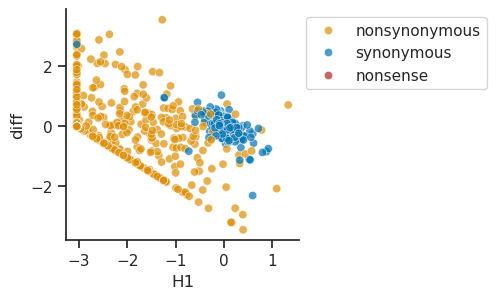

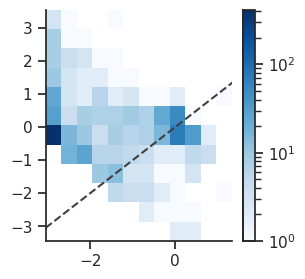

In [ ]:
plt.figure(figsize=[3,3])
sns.scatterplot(x=subtype_1, y='diff', data=data, hue='mut_class', palette=mut_class_colors, alpha=0.7)
# Plot y=x line
# plt.plot([-3.5, 2], [-3.5, 2], color='0.25', linestyle='--')
plt.legend(bbox_to_anchor=(1,1))
sns.despine()
plt.show()

plt.figure(figsize=[3,3])
plt.hist2d(data[subtype_1], data['diff'], bins=12, cmap='Blues', norm='log')
plt.plot([data[subtype_1].min(), 2], [data[subtype_1].min(), 2], color='0.25', linestyle='--')
plt.colorbar()
sns.despine()
plt.show()

Plot distributions of shifts by mutation class

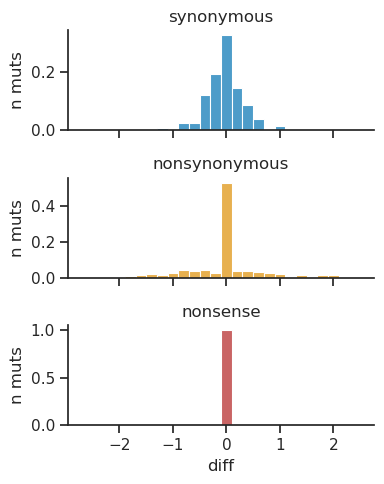

In [ ]:
(fig, axs) = plt.subplots(nrows=3, figsize=(4,5), sharex=True)
bins = np.arange(-2.7, 2.6, 0.2)
for (i, mut_class) in enumerate(['synonymous', 'nonsynonymous', 'nonsense']):
    mut_class_data = data[data['mut_class'] == mut_class]
    sns.histplot(
        x='diff', data=mut_class_data, hue='mut_class', palette=mut_class_colors,
        alpha=0.7, bins=bins, ax=axs[i], stat='probability'
    )
    axs[i].set(
        title=mut_class, ylabel='n muts',
        # yscale='log'
    )
    axs[i].get_legend().remove()
    sns.despine(ax=axs[i])
plt.tight_layout()
plt.show()